# 案例一：回归树拟合正弦曲线

In [1]:
# 导入所需要使用的库
import pandas as pd # pandas是python上类似于excel表格运算的包
import numpy as np # numpy是python上进行科学计算的包
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [21]:
rng = np.random.RandomState(1) # 随机数种子
# rng=1：2 9 8 7 4 2 1
# rng=2：1 8 6 4 3 2 1
X = np.sort(5 * rng.rand(80,1), axis=0) # 生成80个在0～5间取值的数
y = np.sin(X).ravel()
y[::5] += 3 * (0.5-rng.rand(16))

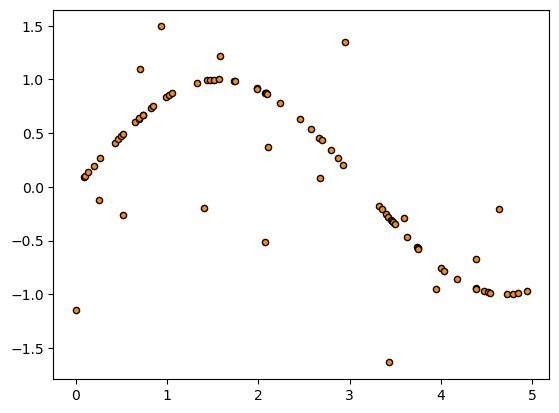

In [22]:
plt.figure()
plt.scatter(X, y, s=20, edgecolors="black", c="darkorange", label="data")

In [23]:
regr_1 = DecisionTreeRegressor(max_depth=2) # 建立好深度为2的回归树模型
regr_2 = DecisionTreeRegressor(max_depth=5) # 建立好深度为1的回归树模型
regr_1.fit(X, y)
regr_2.fit(X, y)

DecisionTreeRegressor(max_depth=5)

In [29]:
# np.arange(0.0, 5.0, 0.01).reshape(-1, 1)
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

In [30]:
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

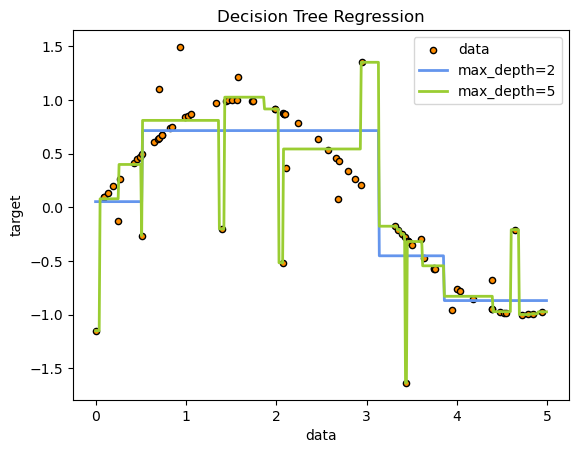

In [32]:
plt.figure()
plt.scatter(X, y, s=20, edgecolors="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()


# 案例二：泰坦尼克号沉没数据集

In [45]:
# 加载需要用的包
import pandas as pd # python中的excel
from sklearn.tree import DecisionTreeClassifier # 决策树分类器
from sklearn.model_selection import train_test_split # 训练集和测试集的划分
from sklearn.model_selection import GridSearchCV # 网格搜索
from sklearn.model_selection import cross_val_score # 交叉验证
import matplotlib.pyplot as plt # 画图的包
import seaborn as sns # 画图的包

In [46]:
data = pd.read_csv("./data.csv", header=0, index_col=0)

data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


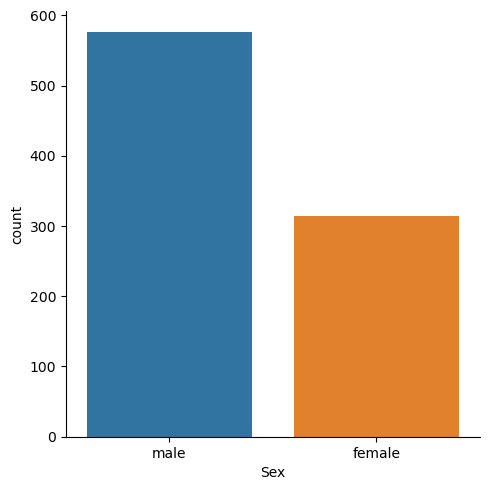

In [48]:
sns.catplot(x="Sex", data=data, kind="count")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


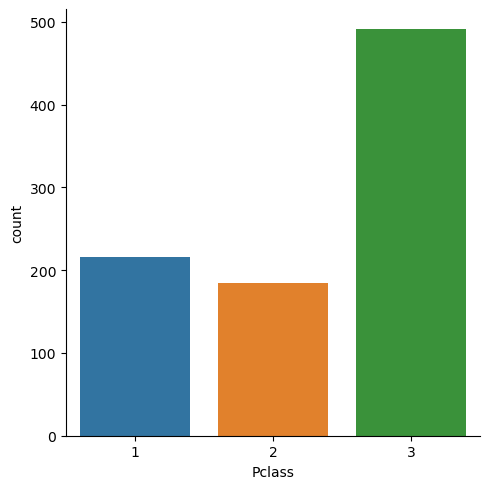

In [49]:
sns.catplot(x="Pclass", data=data, kind="count")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


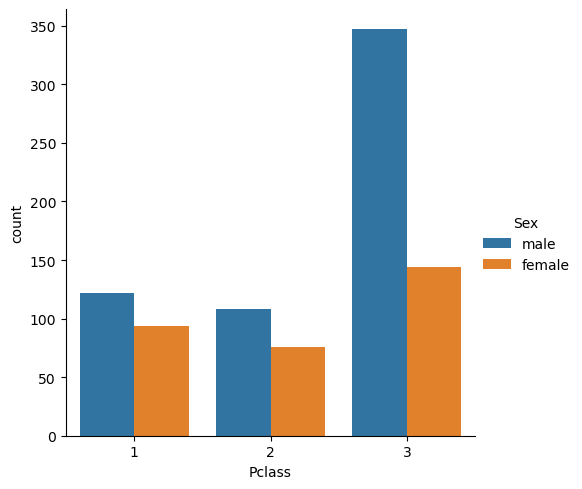

In [50]:
sns.catplot(x="Pclass", data=data, hue="Sex", kind="count")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


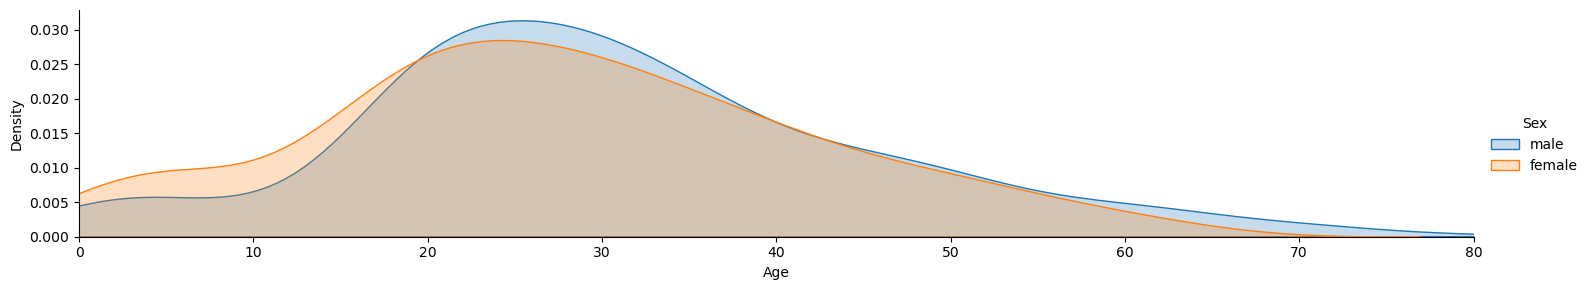

In [53]:
as_fig = sns.FacetGrid(data, hue="Sex", aspect=5)
as_fig.map(sns.kdeplot, "Age", shade=True)
oldest = data["Age"].max()
as_fig.set(xlim=(0, oldest))
as_fig.add_legend()

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


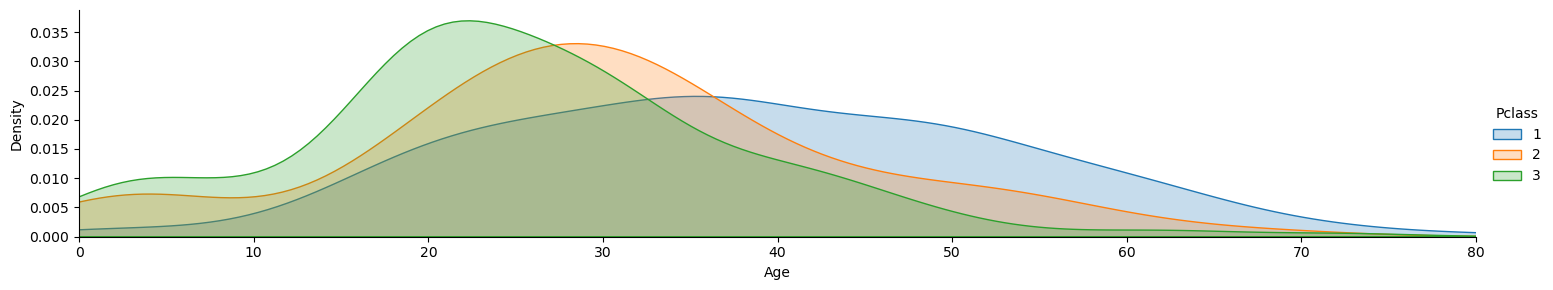

In [54]:
as_fig = sns.FacetGrid(data, hue="Pclass", aspect=5)
as_fig.map(sns.kdeplot, "Age", shade=True)
oldest = data["Age"].max()
as_fig.set(xlim=(0, oldest))
as_fig.add_legend()

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [58]:
data.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [57]:
# 删除列
# 删除缺失值过多的列
# 删除和预测的Y没有关系的列
data.drop(["Cabin", "Name", "Ticket"], axis=1, inplace=True)
# data = data.drop(["Cabin", "Name", "Ticket"], axis=1)

In [60]:
# 处理缺失值
# 如果缺失值比较多-->删除整行
# 如果缺失值不多-->填补
data["Age"] = data["Age"].fillna(data["Age"].mean())

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.6+ KB


In [62]:
data = data.dropna()

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


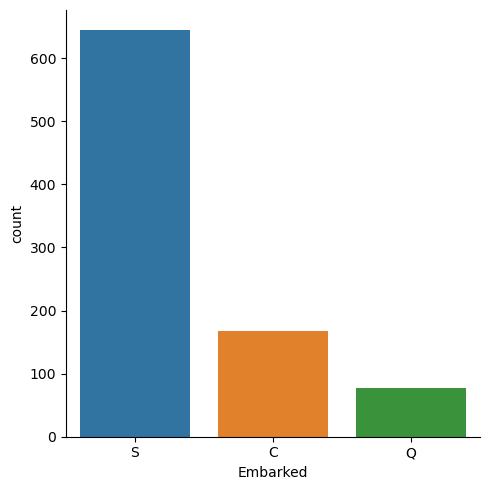

In [64]:
sns.catplot(x="Embarked", data=data, kind="count")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


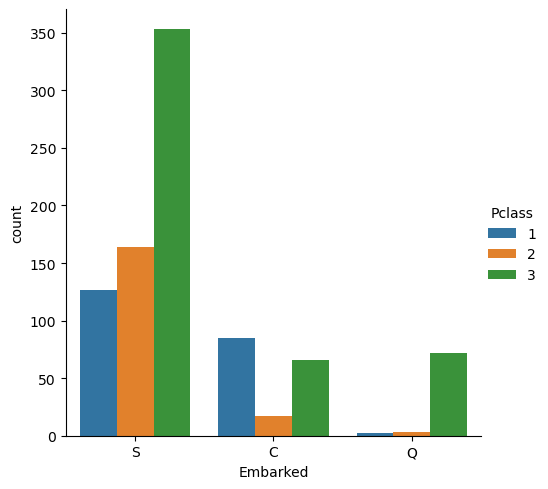

In [65]:
sns.catplot(x="Embarked", data=data, hue="Pclass", kind="count")

In [66]:
data.head(1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.25,S


In [67]:
data["Alone"] = data.SibSp + data.Parch

/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/1471745945.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Alone"] = data.SibSp + data.Parch


In [69]:
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,,
1,0,3,male,22.000000,1,0,7.2500,S,1
2,1,1,female,38.000000,1,0,71.2833,C,1
3,1,3,female,26.000000,0,0,7.9250,S,0
4,1,1,female,35.000000,1,0,53.1000,S,1
5,0,3,male,35.000000,0,0,8.0500,S,0
6,0,3,male,29.699118,0,0,8.4583,Q,0
7,0,1,male,54.000000,0,0,51.8625,S,0
8,0,3,male,2.000000,3,1,21.0750,S,4
9,1,3,female,27.000000,0,2,11.1333,S,2


In [72]:
data["Alone"].loc[data["Alone"] > 0] = "With Family"
data["Alone"].loc[data["Alone"] == 0] = "Without Family"

/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/248308150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Alone"].loc[data["Alone"] > 0] = "With Family"
/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/248308150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Alone"].loc[data["Alone"] == 0] = "Without Family"


In [73]:
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,,
1,0,3,male,22.000000,1,0,7.2500,S,With Family
2,1,1,female,38.000000,1,0,71.2833,C,With Family
3,1,3,female,26.000000,0,0,7.9250,S,Without Family
4,1,1,female,35.000000,1,0,53.1000,S,With Family
5,0,3,male,35.000000,0,0,8.0500,S,Without Family
6,0,3,male,29.699118,0,0,8.4583,Q,Without Family
7,0,1,male,54.000000,0,0,51.8625,S,Without Family
8,0,3,male,2.000000,3,1,21.0750,S,With Family
9,1,3,female,27.000000,0,2,11.1333,S,With Family


/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


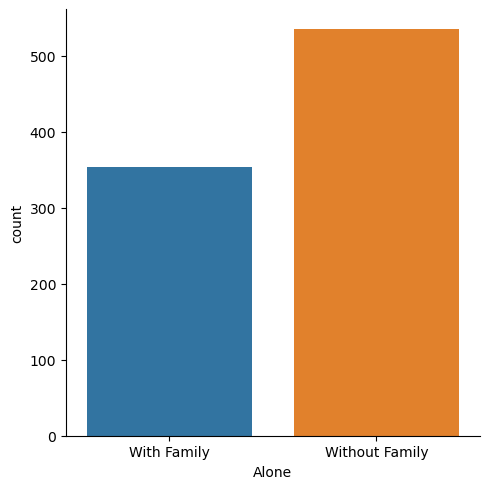

In [74]:
sns.catplot(x="Alone", data=data, kind="count")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


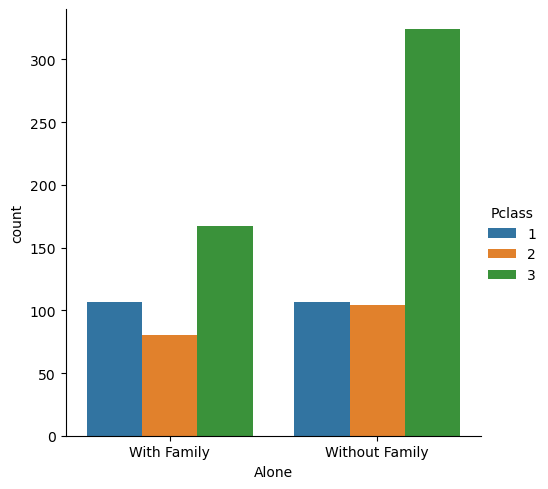

In [75]:
sns.catplot(x="Alone", data=data, kind="count", hue="Pclass")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


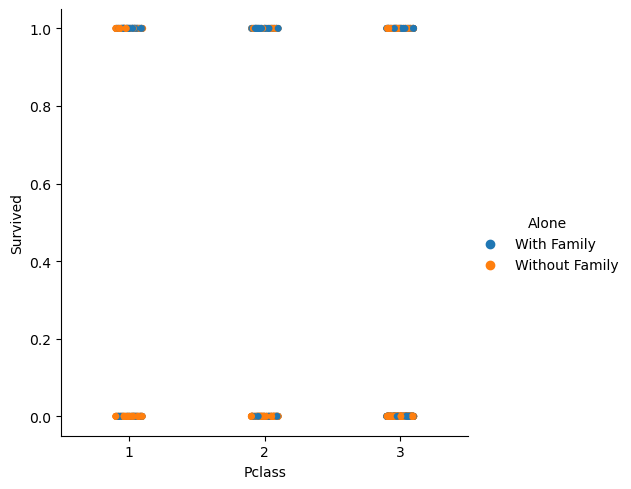

In [78]:
sns.catplot(y="Survived", x="Pclass", data=data, hue="Alone")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


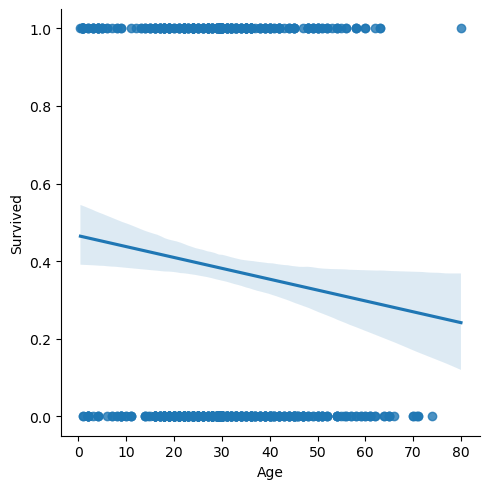

In [81]:
sns.lmplot(data=data, x="Age", y="Survived")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


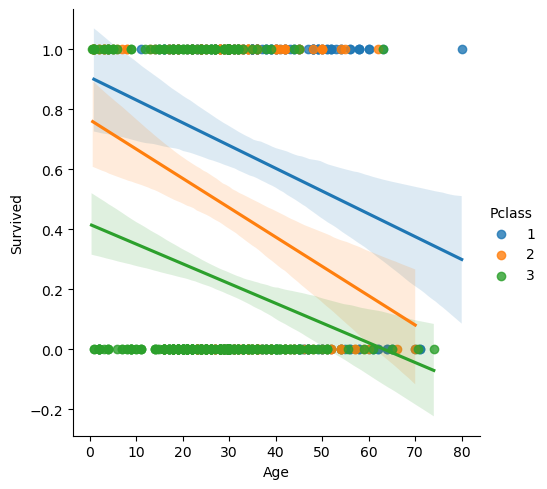

In [82]:
sns.lmplot(data=data, x="Age", y="Survived", hue="Pclass")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


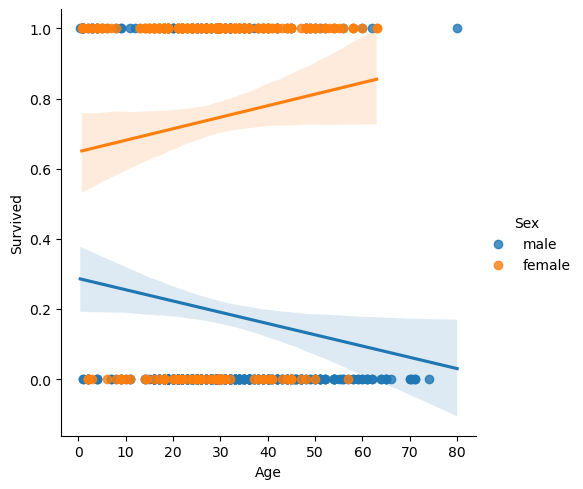

In [83]:
sns.lmplot(data=data, x="Age", y="Survived", hue="Sex")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


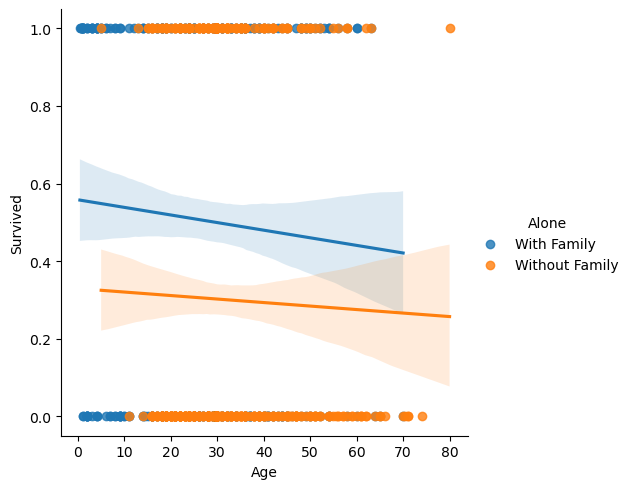

In [84]:
sns.lmplot(data=data, x="Age", y="Survived", hue="Alone")

/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


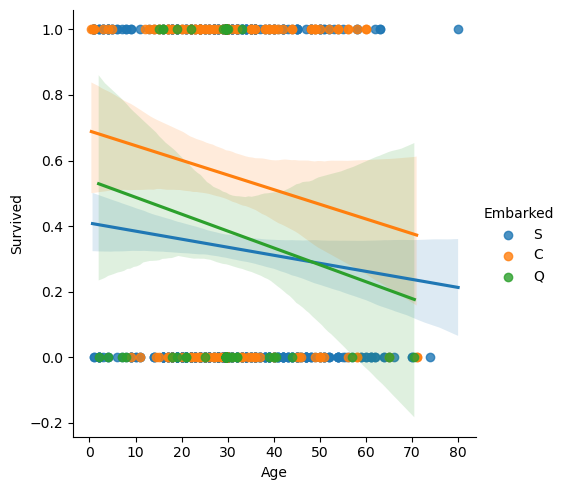

In [85]:
sns.lmplot(data=data, x="Age", y="Survived", hue="Embarked")

In [86]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,,
1,0,3,male,22.000000,1,0,7.2500,S,With Family
2,1,1,female,38.000000,1,0,71.2833,C,With Family
3,1,3,female,26.000000,0,0,7.9250,S,Without Family
4,1,1,female,35.000000,1,0,53.1000,S,With Family
5,0,3,male,35.000000,0,0,8.0500,S,Without Family
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.000000,0,0,13.0000,S,Without Family
888,1,1,female,19.000000,0,0,30.0000,S,Without Family
889,0,3,female,29.699118,1,2,23.4500,S,With Family


In [89]:
# 二分类变量转化为数值型变量
data["Sex"] = (data["Sex"] == "male").astype("int")

# 二分类变量转化为数值型变量
data["Alone"] = (data["Alone"] == "With Family").astype("int")

/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/2655538599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Sex"] = (data["Sex"] == "male").astype("int")
/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/2655538599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Alone"] = (data["Alone"] == "With Family").astype("int")


In [90]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,,
1,0,3,1,22.000000,1,0,7.2500,S,1
2,1,1,0,38.000000,1,0,71.2833,C,1
3,1,3,0,26.000000,0,0,7.9250,S,0
4,1,1,0,35.000000,1,0,53.1000,S,1
5,0,3,1,35.000000,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
887,0,2,1,27.000000,0,0,13.0000,S,0
888,1,1,0,19.000000,0,0,30.0000,S,0
889,0,3,0,29.699118,1,2,23.4500,S,1


In [100]:
labels = data["Embarked"].unique().tolist()

In [103]:
labels.index("Q")

2

In [105]:
# 将三分类变量转换为数值型变量
data["Embarked"] = data["Embarked"].apply(lambda x: labels.index(x))

/var/folders/dj/vh2slqrs4rb24cfqbvbzgs7c0000gn/T/ipykernel_18606/331689819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Embarked"] = data["Embarked"].apply(lambda x: labels.index(x))


In [106]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,,
1,0,3,1,22.000000,1,0,7.2500,0,1
2,1,1,0,38.000000,1,0,71.2833,1,1
3,1,3,0,26.000000,0,0,7.9250,0,0
4,1,1,0,35.000000,1,0,53.1000,0,1
5,0,3,1,35.000000,0,0,8.0500,0,0
...,...,...,...,...,...,...,...,...,...
887,0,2,1,27.000000,0,0,13.0000,0,0
888,1,1,0,19.000000,0,0,30.0000,0,0
889,0,3,0,29.699118,1,2,23.4500,0,1


In [113]:
X = data.iloc[:, data.columns != "Survived"]
y = data.iloc[:, data.columns == "Survived"]

In [114]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.3, random_state=888)

In [115]:
Xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
PassengerId,,,,,,,,
542,3,0,9.000000,4,2,31.2750,0,1
758,2,1,18.000000,0,0,11.5000,0,0
175,1,1,56.000000,0,0,30.6958,1,0
430,3,1,32.000000,0,0,8.0500,0,0
882,3,1,33.000000,0,0,7.8958,0,0
...,...,...,...,...,...,...,...,...
117,3,1,70.500000,0,0,7.7500,2,0
152,1,0,22.000000,1,0,66.6000,0,1
241,3,0,29.699118,1,0,14.4542,1,1


In [119]:
# 恢复索引的循环
for i in [Xtrain, Xtest, Ytrain, Ytest]:
    i.index = range(i.shape[0])


In [121]:
Xtest

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Alone
0,1,1,49.000000,1,0,89.1042,1,1
1,3,0,29.699118,8,2,69.5500,0,1
2,3,1,16.000000,1,3,34.3750,0,1
3,3,1,29.699118,1,0,19.9667,0,1
4,3,1,39.000000,1,5,31.2750,0,1
...,...,...,...,...,...,...,...,...
262,1,0,14.000000,1,2,120.0000,0,1
263,2,0,42.000000,1,0,26.0000,0,1
264,1,0,33.000000,0,0,86.5000,0,0
265,1,0,45.000000,1,1,164.8667,0,1


In [122]:
# 建模三步走
clf = DecisionTreeClassifier(random_state=888)
clf = clf.fit(Xtrain, Ytrain)
score_ = clf.score(Xtest, Ytest) # 测试集分数
score_

0.8014981273408239

In [124]:
# 交叉验证表现
score = cross_val_score(clf, X, y, cv=10)
score.mean()

0.7705822267620019

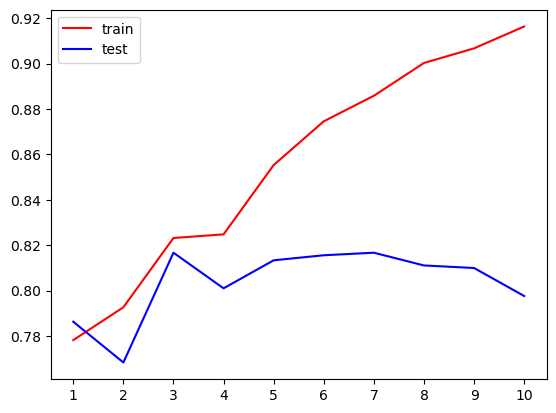

In [127]:
# 针对单一参数进行调参
# 绘制学习曲线
tr = [] # 模型在训练集上的表现
te = [] # 模型在测试集上的表现

for i in range(10):
    clf = DecisionTreeClassifier(random_state=888
                                 ,max_depth=i+1
                                 ,criterion="entropy"
                                 )
    clf = clf.fit(Xtrain, Ytrain)
    score_tr = clf.score(Xtrain, Ytrain) # 单一模型在训练集上的表现
    score_te = cross_val_score(clf, X, y, cv=10).mean() # 单一模型在测试集上的表现，只不过此时测试集是10个的平均
    tr.append(score_tr)
    te.append(score_te)

plt.plot(range(1,11), tr, color="red", label="train")
plt.plot(range(1,11), te, color="blue", label="test")
plt.xticks(range(1,11)) # X 坐标轴范围
plt.legend()
plt.show()




In [129]:
[*range(1,10)]

[1, 2, 3, 4, 5, 6, 7, 8, 9]

array([0.        , 0.02631579, 0.05263158, 0.07894737, 0.10526316,
       0.13157895, 0.15789474, 0.18421053, 0.21052632, 0.23684211,
       0.26315789, 0.28947368, 0.31578947, 0.34210526, 0.36842105,
       0.39473684, 0.42105263, 0.44736842, 0.47368421, 0.5       ])

In [131]:
# 网格搜索调参过程
# 网格搜索时间较长

parameters = {"splitter": ("best", "random")
              ,"criterion": ("gini", "entropy")
              ,"max_depth": [*range(3,7)]
              ,"min_samples_leaf": [*range(1, 50, 5)]
              ,"min_impurity_decrease": [*np.linspace(0, 0.5, 20)]
}

clf = DecisionTreeClassifier(random_state=888)
GS = GridSearchCV(clf, parameters, cv=10)
GS.fit(Xtrain, Ytrain)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=888),
             param_grid={'criterion': ('gini', 'entropy'),
                         'max_depth': [3, 4, 5, 6],
                         'min_impurity_decrease': [0.0, 0.05555555555555555,
                                                   0.1111111111111111,
                                                   0.16666666666666666,
                                                   0.2222222222222222,
                                                   0.2777777777777778,
                                                   0.3333333333333333,
                                                   0.38888888888888884,
                                                   0.4444444444444444, 0.5],
                         'min_samples_leaf': [1, 6],
                         'splitter': ('best', 'random')})

In [132]:
# 输出最佳参数
GS.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'splitter': 'best'}

In [133]:
# 输出最佳分数
GS.best_score_

0.8183819764464925